In [1]:
from e3nn import o3
import torch

In [2]:
o3.Irreps("1x0ee + 1x2oe").randn(-1, 1)

tensor([[ 0.6551],
        [-1.2487],
        [ 1.7822],
        [-1.0203],
        [-1.5565],
        [-0.2599]])

In [3]:
irreps_sh = o3.Irreps.spherical_harmonics(lmax = 2)
print(irreps_sh)

edge_vec = torch.randn(10, 3)

sh = o3.spherical_harmonics(irreps_sh, edge_vec, normalize=True, normalization='component')
# normalize=True ensure that x is divided by |x| before computing the sh

sh.pow(2).mean()  # should be close to 1

1x0ee+1x1oe+1x2ee


tensor(1.)

In [4]:
irreps_input = o3.Irreps("1x0ee + 1x1oe + 1x2ee + 1x0eo + 1x1oo + 1x2eo + 1x0oe + 1x1ee + 1x2oe + 1x0oo + 1x1eo + 1x2oo")
irreps_output = o3.Irreps("1x0ee + 1x0oe + 1x0oo + 1x0eo")

In [5]:
f_in = irreps_input.randn(len(edge_vec), -1)

/Users/temporary/Documents/GitHub/pytorch-intel-mps/torch/jit/_check.py:172: UserWarning: The TorchScript type system doesn't support instance-level annotations on empty non-base types in `__init__`. Instead, either 1) use a type annotation in the class body, or 2) wrap the type in `torch.jit.Attribute`.
  warnings.warn("The TorchScript type system doesn't support "


FullyConnectedTensorProduct(1x0ee+1x1oe+1x2ee+1x0eo+1x1oo+1x2eo+1x0oe+1x1ee+1x2oe+1x0oo+1x1eo+1x2oo x 1x0ee+1x1oe+1x2ee -> 1x0ee+1x0oe+1x0oo+1x0eo | 12 paths | 12 weights) needs 12 weights


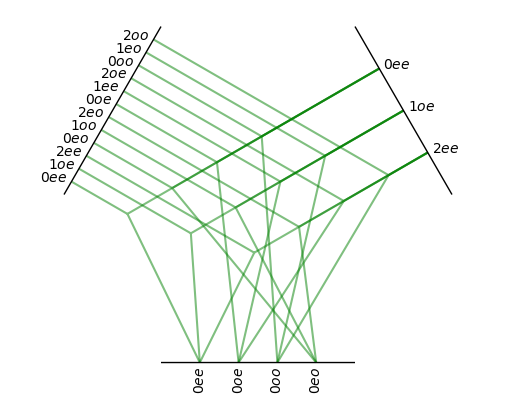

In [6]:
tp = o3.FullyConnectedTensorProduct(irreps_input, irreps_sh, irreps_output, shared_weights=False)

print(f"{tp} needs {tp.weight_numel} weights")

tp.visualize();

In [ ]:
    # Handle simple irreps
    if "l_max" in config:
        l_max = int(config["l_max"])
        parity_setting = config["parity"]
        assert parity_setting in ("o3_full", "o3_restricted", "so3")
        irreps_edge_sh = repr(
            o3.Irreps.spherical_harmonics(
                l_max, p=(1 if parity_setting == "so3" else -1)
            )
        )
        nonscalars_include_parity = parity_setting == "o3_full"
        # check consistant
        assert config.get("irreps_edge_sh", irreps_edge_sh) == irreps_edge_sh
        assert (
            config.get("nonscalars_include_parity", nonscalars_include_parity)
            == nonscalars_include_parity
        )
        config["irreps_edge_sh"] = irreps_edge_sh
        config["nonscalars_include_parity"] = nonscalars_include_parity


In [169]:
irreps_edge_sh = o3.Irreps.spherical_harmonics(
                2, p = 1, t = -1
            )
#irreps_edge_sh = o3.Irreps([(1, (l, p, t)) for l in range(2) for p in [-1, 1] for t in [-1, 1]])

irreps_edge_sh = o3.Irreps([(1, ir) for _, ir in irreps_edge_sh])

In [170]:
irreps_edge_sh.lmax

2

In [171]:
irreps_edge_sh.slices()

[slice(0, 1, None), slice(1, 4, None), slice(4, 9, None)]

In [214]:
i_shift_0 = 0
i_shift_1 = 1
i_shift_2 = 2
ind_0 = []
ind_1 = []
ind_2 = []
for l in range(irreps_edge_sh.lmax + 1):
    ind_0 += list(range(i_shift_0, i_shift_0 + 2*l+1))
    ind_1 += list(range(i_shift_1, i_shift_1 + 2*l+1))
    ind_2 += list(range(i_shift_2, i_shift_2 + 2*l+1))
    
    i_shift_0 += 3*(2*l+1)
    i_shift_1 = i_shift_0 + 2*(l+1) + 1
    i_shift_2 = i_shift_1 + 2*(l+1) + 1
    

In [215]:
ind_0, ind_1, ind_2

([0, 3, 4, 5, 12, 13, 14, 15, 16],
 [1, 6, 7, 8, 17, 18, 19, 20, 21],
 [2, 9, 10, 11, 22, 23, 24, 25, 26])

In [216]:
ind_0 = torch.tensor(ind_0, dtype = torch.long)

final_tensor = torch.zeros((edge_sh.shape[0], edge_sh.shape[-1]*3))

torch.index_copy(final_tensor, -1, ind_0, edge_sh)

tensor([[ 1.0000,  0.0000,  0.0000,  0.3984,  1.6233,  0.4540,  0.0000,  0.0000,
          0.0000,  0.0000,  0.0000,  0.0000,  0.2335,  0.8350,  1.8281,  0.9515,
          0.0306,  0.0000,  0.0000,  0.0000,  0.0000,  0.0000,  0.0000,  0.0000,
          0.0000,  0.0000,  0.0000],
        [ 1.0000,  0.0000,  0.0000,  0.1526, -0.2860,  1.7014,  0.0000,  0.0000,
          0.0000,  0.0000,  0.0000,  0.0000,  0.3352, -0.0564, -1.0266, -0.6282,
          1.8536,  0.0000,  0.0000,  0.0000,  0.0000,  0.0000,  0.0000,  0.0000,
          0.0000,  0.0000,  0.0000],
        [ 1.0000,  0.0000,  0.0000,  1.3039,  0.1606, -1.1288,  0.0000,  0.0000,
          0.0000,  0.0000,  0.0000,  0.0000, -1.9001,  0.2703, -1.0892, -0.2340,
         -0.2749,  0.0000,  0.0000,  0.0000,  0.0000,  0.0000,  0.0000,  0.0000,
          0.0000,  0.0000,  0.0000],
        [ 1.0000,  0.0000,  0.0000, -1.5983,  0.6337,  0.2092,  0.0000,  0.0000,
          0.0000,  0.0000,  0.0000,  0.0000, -0.4316, -1.3076, -0.6690,  0.1711

In [207]:
ind_0

[0, 3, 4, 5, 12, 13, 14, 15, 16]

In [161]:
o3.FullTensorProduct(irreps_edge_sh, o3.FullTensorProduct(irreps_edge_sh, irreps_edge_sh).irreps_out)

FullTensorProduct(3x0ee+3x1oo+3x2ee x 27x0ee+36x1oo+18x1ee+18x2oo+36x2ee+18x3oo+9x3ee+9x4ee -> 108x0oo+297x0ee+567x1oo+405x1ee+459x2oo+621x2ee+432x3oo+351x3ee+162x4oo+243x4ee+81x5oo+54x5ee+27x6ee | 3807 paths | 0 weights)

In [102]:
(irreps_edge_sh + irreps_edge_sh + irreps_edge_sh).lmax #slices()

2

In [181]:
irreps_edge_sh.dim

9

In [220]:
irreps_sh = o3.Irreps([(1, (l, p, t)) for l in range(3) for p in [-1, 1] for t in [-1, 1]])

In [219]:
len(irreps_sh)

12

In [231]:
type(o3.Irreps([(1, ir)  for _, ir in irreps_edge_sh]*3).sort().irreps)

e3nn.o3._irreps.Irreps

In [104]:
?o3.Irreps.spherical_harmonics

In [185]:
edge_sh = o3.SphericalHarmonics(irreps_edge_sh, True, 'component', time_reversal=True, parity = False)(edge_vec)



In [187]:
edge_sh.shape

torch.Size([10, 9])